In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
data = pd.read_csv("/content/healthcare_dataset.csv")

In [56]:
data.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


Higher BMI values are associated with greater chances of diabetes.
Older patients show high blood presure, indicating age related risk

In [57]:
data.shape

(6000, 7)

In [58]:
data.dtypes

,0
patient_id,int64
age,int64
bmi,float64
exercise_hours_per_week,float64
smoker,int64
blood_pressure,float64
diabetes,int64


In [59]:
data.isnull().sum()

,0
patient_id,0
age,0
bmi,0
exercise_hours_per_week,0
smoker,0
blood_pressure,0
diabetes,0


In [60]:
data.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


In [61]:
data['diabetes'].value_counts()

,count
diabetes,
0,5458
1,542


In [62]:
data.groupby('diabetes')['age'].mean()

,age
diabetes,
0,50.376878
1,58.463100


In [63]:
data.groupby('diabetes')['bmi'].mean()

,bmi
diabetes,
0,25.727996
1,28.686716


In [64]:
data.corr()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
patient_id,1.000000,-0.012029,-0.002037,0.007776,-0.000466,-0.019743,0.000734
age,-0.012029,1.000000,0.000622,-0.025014,0.013981,0.711919,0.118743
bmi,-0.002037,0.000622,1.000000,0.015794,0.005261,0.353764,0.170992
exercise_hours_per_week,0.007776,-0.025014,0.015794,1.000000,0.005964,-0.012480,-0.000911
smoker,-0.000466,0.013981,0.005261,0.005964,1.000000,0.426725,-0.006799
blood_pressure,-0.019743,0.711919,0.353764,-0.012480,0.426725,1.000000,0.149009
diabetes,0.000734,0.118743,0.170992,-0.000911,-0.006799,0.149009,1.000000


Data Visualization

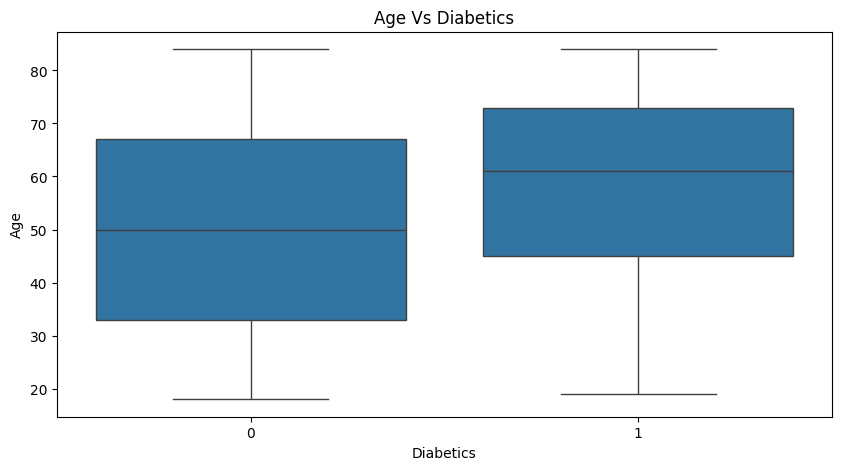

In [65]:
#1. Distribution of Age Vs Diabetics
plt.figure(figsize=(10,5))
sns.boxplot(x='diabetes', y='age', data=data)
plt.title('Age Vs Diabetics')
plt.xlabel('Diabetics')
plt.ylabel('Age')
plt.show()


The dataset suggests that diabetes is more prevalent among older individuals, while younger people are less represented in the diabetic group.

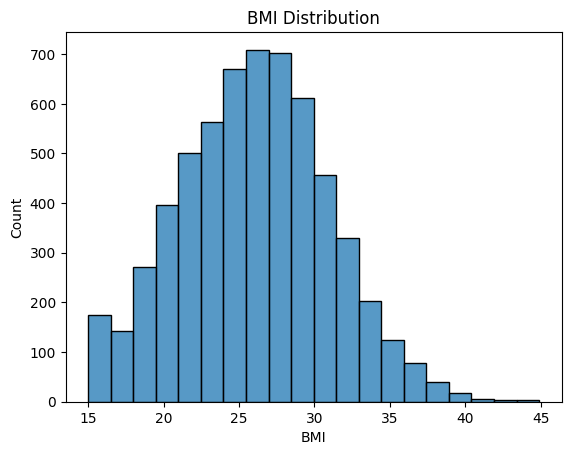

In [66]:
# 2. BMI distribution
sns.histplot(data['bmi'],bins = 20)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

Most individuals cluster around the normal BMI range, but there’s a significant portion in overweight/obese ranges, which could be relevant for health risks like diabetes

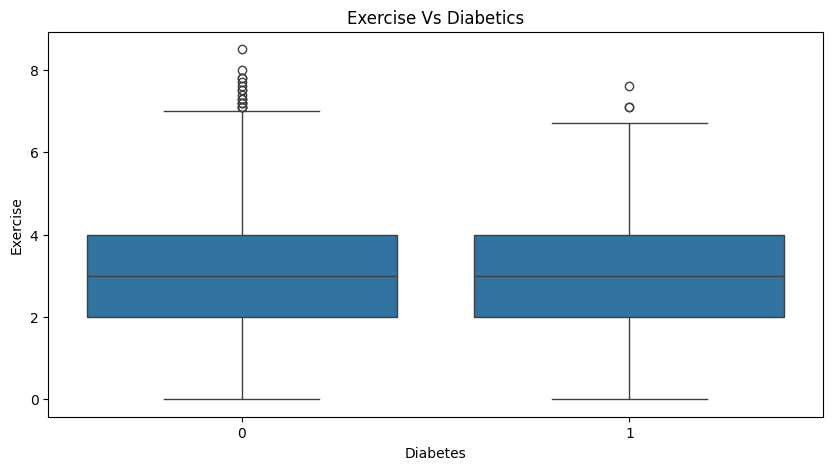

In [67]:
#3. Exercise Vs Diabetics
plt.figure(figsize=(10,5))
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=data)
plt.title('Exercise Vs Diabetics')
plt.xlabel('Diabetes')
plt.ylabel('Exercise')
plt.show()

Both diabetic (1) and non-diabetic (0) groups show nearly the same median exercise levels, suggesting no strong difference in central tendency.

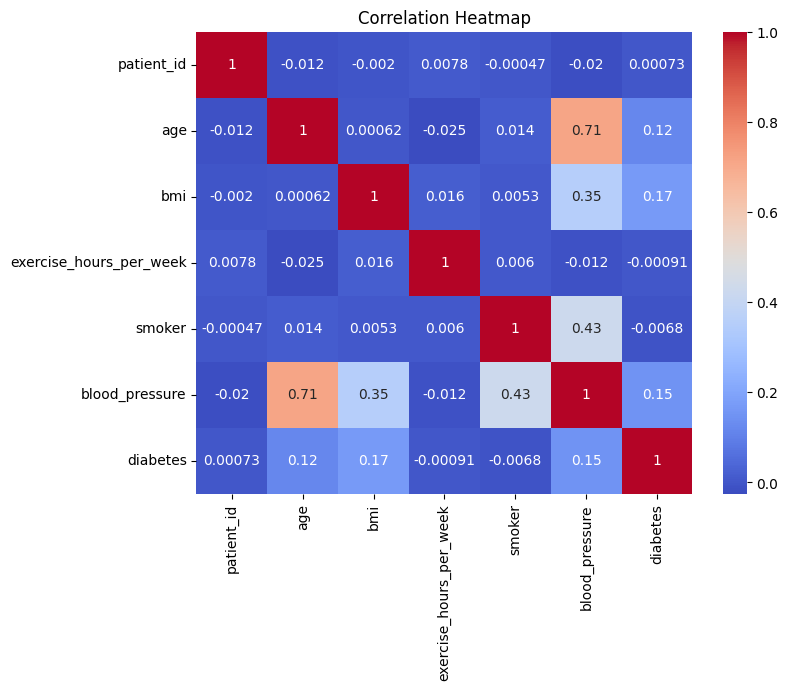

In [68]:
#4.Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True,cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Age → Diabetics skew older.
BMI → Higher BMI is more common among diabetics.
Blood Pressure → Strongly tied to age and moderately linked to diabetes.

Part 2 - Machine Learning Classification Model

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [70]:
x = data.drop(['diabetes','patient_id'],axis = 1)
y = data['diabetes']

In [71]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.85)

In [72]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [73]:
model = LogisticRegression()
model.fit(x_train_scaled,y_train)

LogisticRegression()

In [74]:
y_pred = model.predict(x_test_scaled)

In [75]:
#Evaluate Model Performance
accuracy = accuracy_score(y_test,y_pred)
confusion = confusion_matrix(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [76]:
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion)
print("Precision:", precision)
print("Recall:", recall)
print("f1_core:", f1)

Accuracy: 0.9033333333333333
Confusion Matrix:
 [[813   0]
 [ 87   0]]
Precision: 0.0
Recall: 0.0
f1_core: 0.0


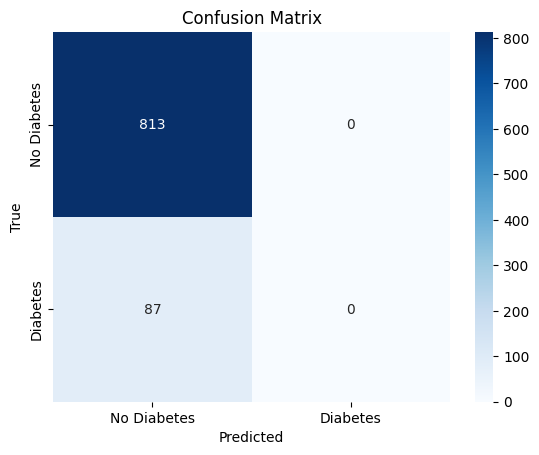

In [77]:
#Confusion matrix visualization
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',xticklabels=['No Diabetes','Diabetes'],
            yticklabels= ['No Diabetes','Diabetes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [78]:
importance = pd.Series(model.coef_[0], index=x.columns)
importance.sort_values(ascending=False)

,0
bmi,0.564527
age,0.342879
blood_pressure,0.150609
exercise_hours_per_week,-0.008945
smoker,-0.169105


Part 3 - Neural Network Model

In [83]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [84]:
nn_model=keras.Sequential(
    [
        layers.Input(shape=(x_train.shape[1],),name='input'),
        layers.Dense(32,activation='relu',name='hidden_layer_1'),
        layers.Dense(16,activation='relu',name='hidden_layer_2'),
        layers.Dense(1,activation='sigmoid',name='output_layer')
    ]
)

In [85]:
nn_model.compile(
    optimizer='adam',
    loss=keras.losses.BinaryCrossentropy(name='binary_cross_entopy'),
    metrics=[
        keras.metrics.BinaryAccuracy(name='Accuracy'),
        keras.metrics.MeanSquaredError(name='MSE')
    ]
)

In [87]:

history =nn_model.fit(x_train,y_train,epochs=50,validation_data=(x_test,y_test))

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Accuracy: 0.9102 - MSE: 0.0792 - loss: 0.2878 - val_Accuracy: 0.9044 - val_MSE: 0.0877 - val_loss: 0.3100
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Accuracy: 0.9110 - MSE: 0.0817 - loss: 0.2995 - val_Accuracy: 0.9033 - val_MSE: 0.0856 - val_loss: 0.3043
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Accuracy: 0.9094 - MSE: 0.0819 - loss: 0.2991 - val_Accuracy: 0.9033 - val_MSE: 0.0855 - val_loss: 0.3047
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Accuracy: 0.9106 - MSE: 0.0795 - loss: 0.2879 - val_Accuracy: 0.9033 - val_MSE: 0.0855 - val_loss: 0.3044
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Accuracy: 0.9104 - MSE: 0.0794 - loss: 0.2878 - val_Accuracy: 0.9033 - val_MSE: 0.0857 - val_loss: 0.3060
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Accuracy: 0.9104 - MSE: 0.0798 - loss: 0.2895 - val_Accuracy: 0.9033 - val_MSE: 0.0863 - val_loss: 0.3040
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 

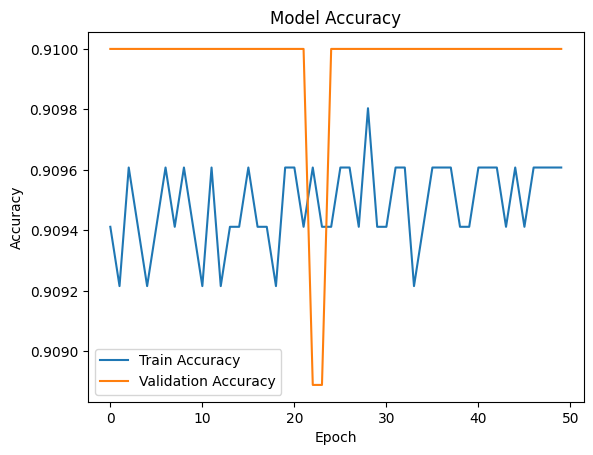

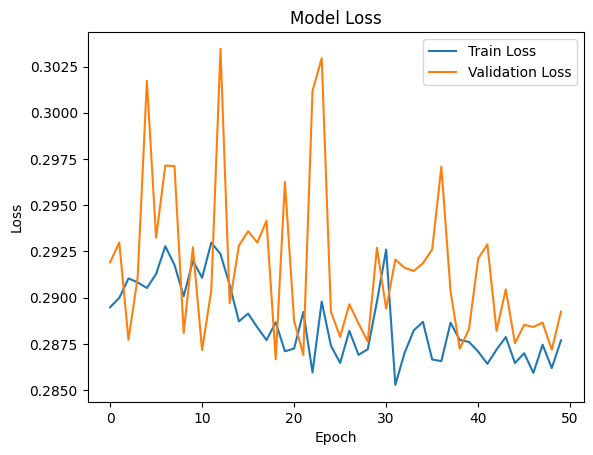

In [ ]:

# Plot Accuracy
plt.plot(history.history['Accuracy'], label='Train Accuracy')
plt.plot(history.history['val_Accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()